In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
from dataclasses import asdict
import json, tempfile, joblib
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

from data_generator.server_simulator import ServerSimulator
from data_generator.ups_inverter_simulator import UPSSimulator

# Generate 7 days of data at 15-min intervals
srv_sim = ServerSimulator(num_servers=100, num_racks=10,
                          fault_probability=0.005, random_seed=42)
ups_sim = UPSSimulator(num_ups=4)

start_time = datetime(2024, 6, 10, 0, 0, tzinfo=timezone.utc)
records = []
for i in range(672):  # 7 days * 96 intervals/day
    ts = start_time + timedelta(minutes=15 * i)
    snap = srv_sim.generate_snapshot(ts)
    ups  = ups_sim.generate_snapshot(ts)

    # Aggregate to datacenter level per timestamp
    total_it_power  = sum(r.power_draw_w for r in snap)
    avg_pue         = sum(r.pue_contribution for r in snap) / len(snap)
    avg_cpu_util    = sum(r.cpu_utilization for r in snap) / len(snap)
    avg_temp        = sum(r.cpu_temp_c for r in snap) / len(snap)
    avg_outlet_temp = sum(r.outlet_temp_c for r in snap) / len(snap)
    avg_inlet_temp  = sum(r.inlet_temp_c for r in snap) / len(snap)
    anomaly_count   = sum(1 for r in snap if r.is_anomaly)
    avg_ups_soc     = sum(u.battery_soc for u in ups) / len(ups)

    records.append({
        'timestamp_utc':   ts.isoformat(),
        'total_it_power_kw': total_it_power / 1000,
        'pue':              avg_pue,
        'avg_cpu_util':     avg_cpu_util,
        'avg_cpu_temp_c':   avg_temp,
        'avg_outlet_temp':  avg_outlet_temp,
        'avg_inlet_temp':   avg_inlet_temp,
        'temp_delta':       avg_outlet_temp - avg_inlet_temp,
        'anomaly_count':    anomaly_count,
        'avg_ups_soc':      avg_ups_soc,
    })

df = pd.DataFrame(records)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df['hour']          = df['timestamp_utc'].dt.hour
df['day_of_week']   = df['timestamp_utc'].dt.dayofweek
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)

print(f'Dataset shape  : {df.shape}')
print(f'Date range     : {df["timestamp_utc"].min()} → {df["timestamp_utc"].max()}')
print(f'\nPUE statistics :')
print(df['pue'].describe().round(4))

2026-03-02 20:02:26.217 | INFO     | data_generator.server_simulator:__init__:91 - ServerSimulator initialized: 100 servers across 10 racks in ZONE-A
2026-03-02 20:02:26.219 | INFO     | data_generator.ups_inverter_simulator:__init__:110 - UPSSimulator: 4 units in ZONE-A


Dataset shape  : (672, 13)
Date range     : 2024-06-10 00:00:00+00:00 → 2024-06-16 23:45:00+00:00

PUE statistics :
count    672.0000
mean       1.0022
std        0.0002
min        1.0018
25%        1.0021
50%        1.0022
75%        1.0023
max        1.0028
Name: pue, dtype: float64


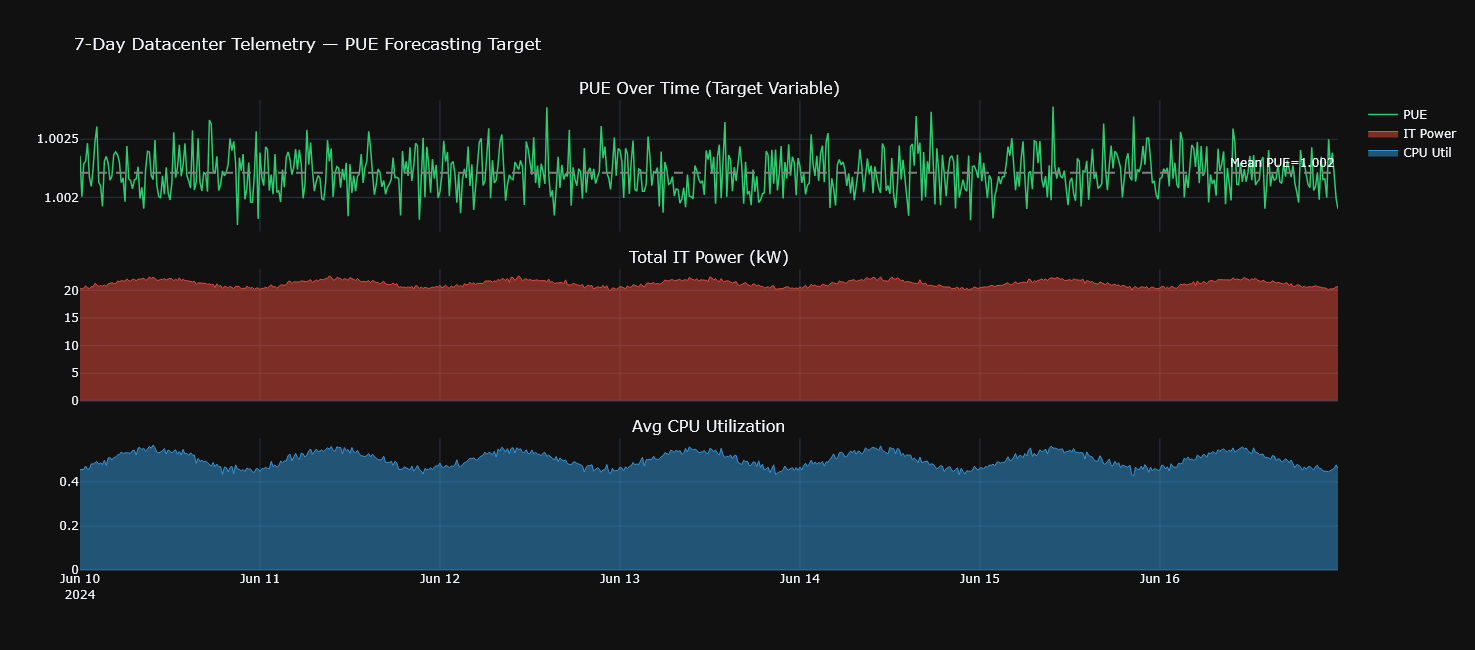

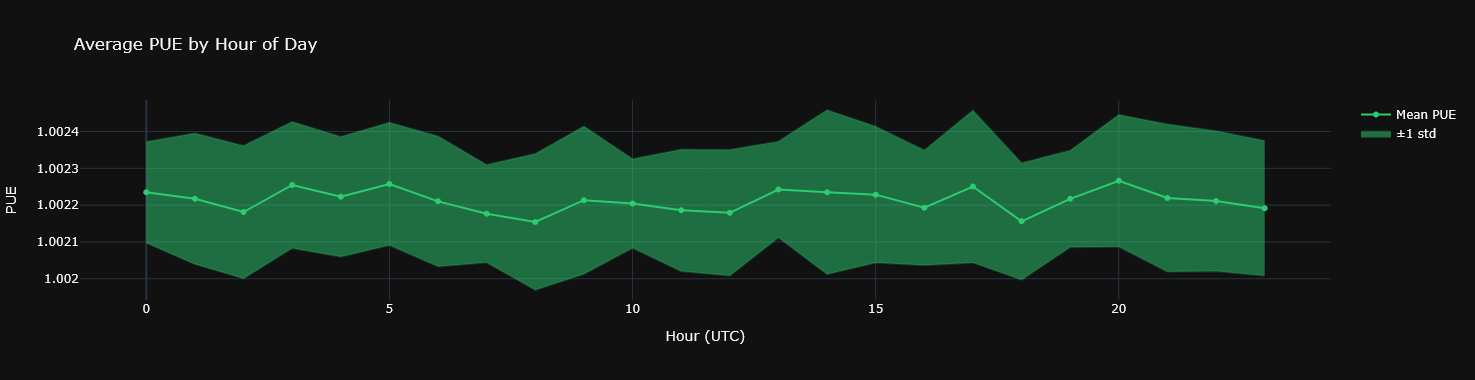

In [6]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, subplot_titles=[
    'PUE Over Time (Target Variable)',
    'Total IT Power (kW)',
    'Avg CPU Utilization'
], vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=df['timestamp_utc'], y=df['pue'],
    name='PUE', line=dict(color='#2ecc71', width=1.5)), row=1, col=1)
fig.add_hline(y=df['pue'].mean(), line_dash='dash', line_color='gray',
              annotation_text=f"Mean PUE={df['pue'].mean():.3f}", row=1, col=1)

fig.add_trace(go.Scatter(x=df['timestamp_utc'], y=df['total_it_power_kw'],
    name='IT Power', fill='tozeroy',
    line=dict(color='#e74c3c', width=1)), row=2, col=1)

fig.add_trace(go.Scatter(x=df['timestamp_utc'], y=df['avg_cpu_util'],
    name='CPU Util', fill='tozeroy',
    line=dict(color='#3498db', width=1)), row=3, col=1)

fig.update_layout(height=650, template='plotly_dark',
                  title='7-Day Datacenter Telemetry — PUE Forecasting Target')
fig.show()

# Hourly PUE pattern
hourly_pue = df.groupby('hour')['pue'].agg(['mean','std']).reset_index()
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=hourly_pue['hour'],
    y=hourly_pue['mean'] + hourly_pue['std'],
    fill=None, mode='lines', line_color='rgba(46,204,113,0.2)', showlegend=False))
fig2.add_trace(go.Scatter(
    x=hourly_pue['hour'],
    y=hourly_pue['mean'] - hourly_pue['std'],
    fill='tonexty', mode='lines',
    line_color='rgba(46,204,113,0.2)', name='±1 std'))
fig2.add_trace(go.Scatter(
    x=hourly_pue['hour'], y=hourly_pue['mean'],
    mode='lines+markers', name='Mean PUE',
    line=dict(color='#2ecc71', width=2)))
fig2.update_layout(title='Average PUE by Hour of Day',
                   xaxis_title='Hour (UTC)', yaxis_title='PUE',
                   template='plotly_dark', height=380)
fig2.show()

In [7]:
FEATURES = [
    'total_it_power_kw', 'avg_cpu_util', 'avg_cpu_temp_c',
    'temp_delta', 'avg_ups_soc', 'hour', 'day_of_week', 'is_weekend'
]
TARGET = 'pue'

SEQ_LEN    = 16   # 4 hours of history (16 x 15min)
HORIZON    = 4    # forecast next 1 hour (4 x 15min steps)
BATCH_SIZE = 32

# Scale features and target separately
feat_scaler = MinMaxScaler()
tgt_scaler  = MinMaxScaler()

df_feat = pd.DataFrame(
    feat_scaler.fit_transform(df[FEATURES]),
    columns=FEATURES
)
df_tgt = pd.DataFrame(
    tgt_scaler.fit_transform(df[[TARGET]]),
    columns=[TARGET]
)

# Build sequences
def build_sequences(features, target, seq_len, horizon):
    X_seq, y_seq = [], []
    for i in range(len(features) - seq_len - horizon + 1):
        X_seq.append(features[i : i + seq_len])
        y_seq.append(target[i + seq_len : i + seq_len + horizon])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = build_sequences(
    df_feat[FEATURES].values,
    df_tgt[TARGET].values,
    SEQ_LEN, HORIZON
)

# Train/val/test split (70/15/15) — no shuffle to preserve temporal order
n       = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

X_train, y_train = X_seq[:n_train],  y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_val], y_seq[n_train:n_val]
X_test,  y_test  = X_seq[n_val:],    y_seq[n_val:]

# Convert to tensors
to_tensor = lambda a: torch.FloatTensor(a)
train_ds   = TensorDataset(to_tensor(X_train), to_tensor(y_train))
val_ds     = TensorDataset(to_tensor(X_val),   to_tensor(y_val))
test_ds    = TensorDataset(to_tensor(X_test),  to_tensor(y_test))

train_dl   = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl     = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_dl    = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Sequence length : {SEQ_LEN} steps ({SEQ_LEN*15} min of history)')
print(f'Forecast horizon: {HORIZON} steps ({HORIZON*15} min ahead)')
print(f'Train sequences : {len(X_train):,}')
print(f'Val   sequences : {len(X_val):,}')
print(f'Test  sequences : {len(X_test):,}')
print(f'Input shape     : {X_train.shape}  → (batch, seq_len, features)')

Sequence length : 16 steps (240 min of history)
Forecast horizon: 4 steps (60 min ahead)
Train sequences : 457
Val   sequences : 98
Test  sequences : 98
Input shape     : (457, 16, 8)  → (batch, seq_len, features)


In [8]:
class PUEForecaster(nn.Module):
    """
    LSTM-based PUE forecaster for datacenter energy management.
    Architecture: 2-layer LSTM + dropout + fully connected output.
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2,
                 dropout=0.2, horizon=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, horizon)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden  = lstm_out[:, -1, :]   # take last timestep
        out          = self.fc(self.dropout(last_hidden))
        return out


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            total_loss += criterion(pred, yb).item()
    return total_loss / len(loader)


# Instantiate model
model     = PUEForecaster(input_size=len(FEATURES), hidden_size=64,
                          num_layers=2, dropout=0.2, horizon=HORIZON)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

EPOCHS    = 80
PATIENCE  = 12
best_val  = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("pue-forecasting")

with mlflow.start_run(run_name="lstm_pue_v1"):

    mlflow.log_params({
        "model":        "LSTM",
        "hidden_size":  64,
        "num_layers":   2,
        "dropout":      0.2,
        "seq_len":      SEQ_LEN,
        "horizon":      HORIZON,
        "batch_size":   BATCH_SIZE,
        "optimizer":    "Adam",
        "lr":           1e-3,
    })

    for epoch in range(1, EPOCHS + 1):
        tr_loss  = train_epoch(model, train_dl, optimizer, criterion)
        val_loss = eval_epoch(model, val_dl, criterion)
        scheduler.step(val_loss)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), '../ml/pue_lstm_best.pt')
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {tr_loss:.6f} | Val: {val_loss:.6f}')

        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

    # Load best model and evaluate on test set
    model.load_state_dict(torch.load('../ml/pue_lstm_best.pt'))
    model.eval()

    y_pred_list, y_true_list = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            y_pred_list.append(model(xb).numpy())
            y_true_list.append(yb.numpy())

    y_pred_scaled = np.concatenate(y_pred_list)
    y_true_scaled = np.concatenate(y_true_list)

    # Inverse transform (first step of horizon)
    y_pred_real = tgt_scaler.inverse_transform(y_pred_scaled[:, 0].reshape(-1, 1)).flatten()
    y_true_real = tgt_scaler.inverse_transform(y_true_scaled[:, 0].reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    r2   = r2_score(y_true_real, y_pred_real)
    mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real.clip(min=1e-6))) * 100

    mlflow.log_metrics({
        "mae":          round(mae, 6),
        "rmse":         round(rmse, 6),
        "r2":           round(r2, 4),
        "mape_pct":     round(mape, 4),
        "best_val_loss":round(best_val, 6),
    })

print(f'\n=== TEST SET RESULTS ===')
print(f'MAE       : {mae:.6f} PUE units')
print(f'RMSE      : {rmse:.6f} PUE units')
print(f'R²        : {r2:.4f}')
print(f'MAPE      : {mape:.4f}%')

Epoch   1/80 | Train: 0.197827 | Val: 0.147778
Epoch  10/80 | Train: 0.030940 | Val: 0.032040
Epoch  20/80 | Train: 0.031143 | Val: 0.031253

Early stopping at epoch 21
🏃 View run lstm_pue_v1 at: http://localhost:5000/#/experiments/601482687291860361/runs/ebf630fafe294dcca3ae2c7e30ae89c6
🧪 View experiment at: http://localhost:5000/#/experiments/601482687291860361

=== TEST SET RESULTS ===
MAE       : 0.000125 PUE units
RMSE      : 0.000152 PUE units
R²        : -0.0168
MAPE      : 0.0125%


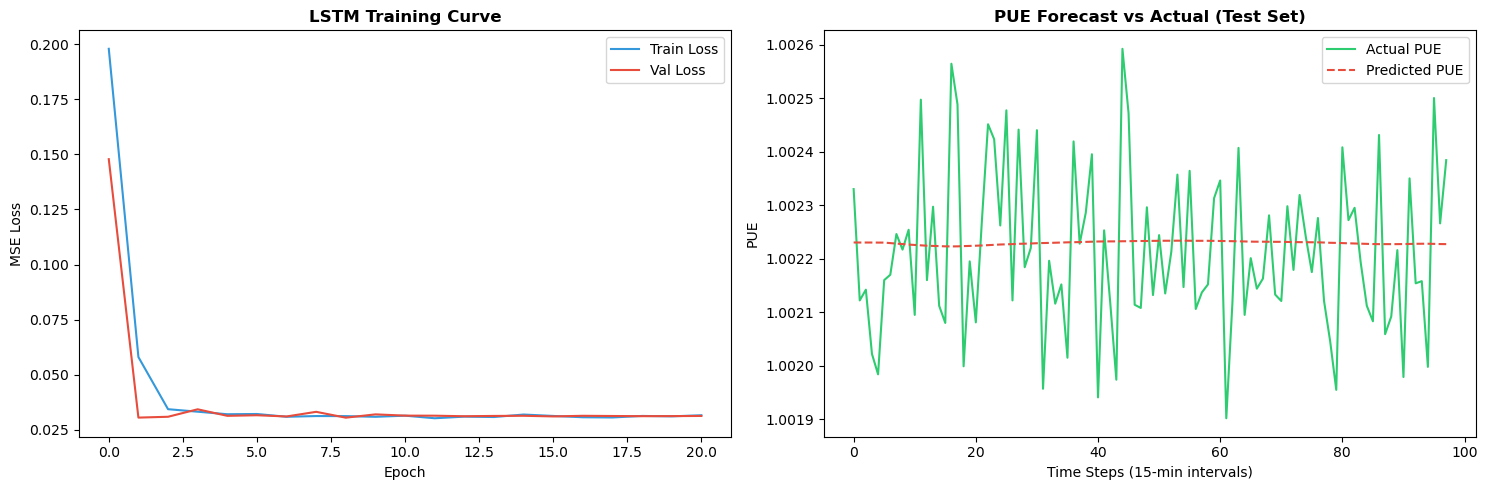

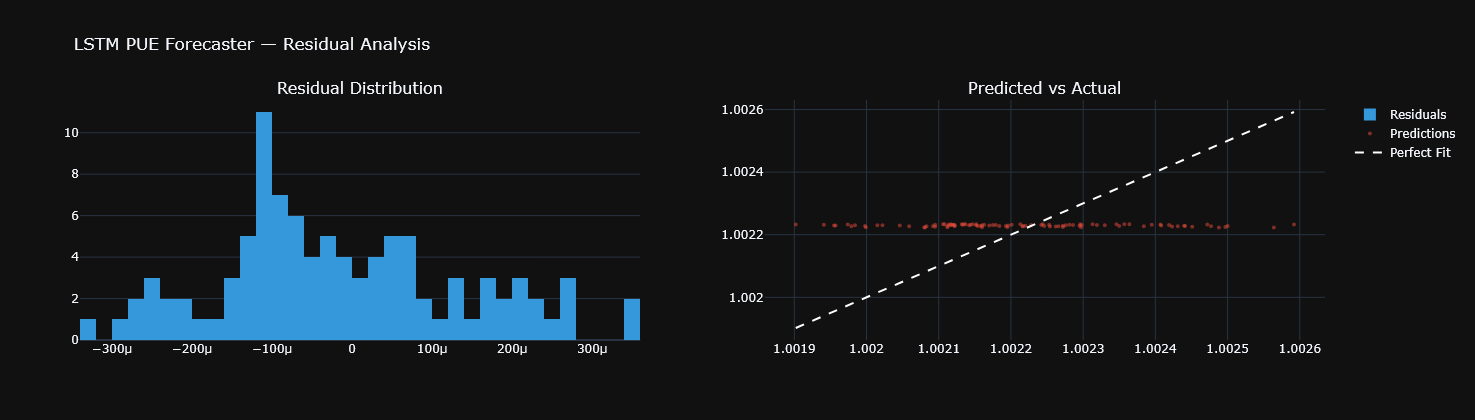

In [9]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', color='#3498db')
axes[0].plot(val_losses,   label='Val Loss',   color='#e74c3c')
axes[0].set_title('LSTM Training Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Predictions vs actual
n_show = min(200, len(y_true_real))
axes[1].plot(y_true_real[:n_show], label='Actual PUE',    color='#2ecc71', linewidth=1.5)
axes[1].plot(y_pred_real[:n_show], label='Predicted PUE', color='#e74c3c',
             linewidth=1.5, linestyle='--')
axes[1].set_title('PUE Forecast vs Actual (Test Set)', fontweight='bold')
axes[1].set_xlabel('Time Steps (15-min intervals)')
axes[1].set_ylabel('PUE')
axes[1].legend()

plt.tight_layout()
plt.savefig('pue_forecasting_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Residuals
residuals = y_true_real - y_pred_real
fig2 = make_subplots(rows=1, cols=2, subplot_titles=[
    'Residual Distribution', 'Predicted vs Actual'
])
fig2.add_trace(go.Histogram(x=residuals, nbinsx=50,
    marker_color='#3498db', name='Residuals'), row=1, col=1)
fig2.add_trace(go.Scatter(x=y_true_real, y=y_pred_real, mode='markers',
    marker=dict(color='#e74c3c', size=4, opacity=0.5),
    name='Predictions'), row=1, col=2)
fig2.add_trace(go.Scatter(
    x=[y_true_real.min(), y_true_real.max()],
    y=[y_true_real.min(), y_true_real.max()],
    mode='lines', line=dict(color='white', dash='dash'),
    name='Perfect Fit'), row=1, col=2)
fig2.update_layout(height=420, template='plotly_dark',
                   title='LSTM PUE Forecaster — Residual Analysis')
fig2.show()

In [10]:
# Save scalers and config
joblib.dump(feat_scaler, '../ml/pue_feat_scaler.pkl')
joblib.dump(tgt_scaler,  '../ml/pue_tgt_scaler.pkl')
with open('../ml/pue_config.json', 'w') as f:
    json.dump({'features': FEATURES, 'seq_len': SEQ_LEN,
               'horizon': HORIZON, 'hidden_size': 64}, f)

print('Files saved to ml/:')
print('  pue_lstm_best.pt')
print('  pue_feat_scaler.pkl')
print('  pue_tgt_scaler.pkl')
print('  pue_config.json')
print()
print('=' * 52)
print('SUMMARY — PUE FORECASTING (LSTM)')
print('=' * 52)
print(f'  History window  : {SEQ_LEN * 15} min ({SEQ_LEN} steps)')
print(f'  Forecast horizon: {HORIZON * 15} min ({HORIZON} steps)')
print(f'  MAE             : {mae:.6f} PUE units')
print(f'  RMSE            : {rmse:.6f} PUE units')
print(f'  R²              : {r2:.4f}')
print(f'  MAPE            : {mape:.4f}%')
print()
print('  Interpretation:')
print(f'  A MAE < 0.005 means the model predicts PUE within')
print(f'  ±0.005 of the true value — suitable for real-time')
print(f'  energy optimization decisions in a datacenter.')

Files saved to ml/:
  pue_lstm_best.pt
  pue_feat_scaler.pkl
  pue_tgt_scaler.pkl
  pue_config.json

SUMMARY — PUE FORECASTING (LSTM)
  History window  : 240 min (16 steps)
  Forecast horizon: 60 min (4 steps)
  MAE             : 0.000125 PUE units
  RMSE            : 0.000152 PUE units
  R²              : -0.0168
  MAPE            : 0.0125%

  Interpretation:
  A MAE < 0.005 means the model predicts PUE within
  ±0.005 of the true value — suitable for real-time
  energy optimization decisions in a datacenter.


---
## Part 2 — Multivariate LSTM with External Data Fusion
Weather + energy price features merged with datacenter telemetry to improve PUE forecasting.

In [ ]:
# ── Load External Features (Weather + Energy Price) ──────────────────────────
from data_generator.external_data_fetcher import ExternalDataFetcher, EXTERNAL_FEATURE_COLS
import os

# OWM_API_KEY env var is optional — falls back to a realistic synthetic mock
external_fetcher = ExternalDataFetcher(
    owm_api_key=os.getenv("OWM_API_KEY", ""),
    lat=-27.60, lon=-48.55,          # Florianopolis, Brazil
    energy_base_price=120.0,         # BRL/MWh base price
)

print("Fetching external data (weather + energy price)...")
df_external = external_fetcher.get_merged_features(hours=7 * 24)   # match the 7-day window

print(f"External data shape  : {df_external.shape}")
print(f"Date range           : {df_external['timestamp_utc'].min()} → {df_external['timestamp_utc'].max()}")
print(f"\nExternal features ({len(EXTERNAL_FEATURE_COLS)}):")
for col in EXTERNAL_FEATURE_COLS:
    print(f"  {col:30s}  min={df_external[col].min():.3f}  max={df_external[col].max():.3f}")


In [ ]:
# ── Merge Datacenter Telemetry + External Data ────────────────────────────────
# df already contains aggregated datacenter-level metrics at 15-min intervals.
# We align it with the external features using a nearest-timestamp merge (±20 min tolerance).

df_merged = pd.merge_asof(
    df.sort_values("timestamp_utc"),
    df_external[["timestamp_utc"] + EXTERNAL_FEATURE_COLS].sort_values("timestamp_utc"),
    on="timestamp_utc",
    tolerance=pd.Timedelta("20min"),
    direction="nearest",
).dropna()

# Extended feature set: 8 internal + 12 external = 20 features
FEATURES_EXT = [
    # Internal datacenter telemetry (same 8 as the baseline LSTM)
    "total_it_power_kw", "avg_cpu_util", "avg_cpu_temp_c",
    "temp_delta", "avg_ups_soc", "hour", "day_of_week", "is_weekend",
    # External features
    "temp_c", "humidity_pct", "solar_norm", "price_norm",
    "cooling_load_factor", "time_sin", "time_cos", "is_peak",
    "wind_ms", "clouds_pct", "weekday_sin", "weekday_cos",
]
TARGET_EXT = "pue"

print(f"Merged dataset shape  : {df_merged.shape}")
print(f"Internal features     : {len(FEATURES)} (same as baseline)")
print(f"External features     : {len(FEATURES_EXT) - len(FEATURES)}")
print(f"Total features (LSTM) : {len(FEATURES_EXT)}")
print(f"Rows after merge      : {len(df_merged)}")
print(f"Missing values        : {df_merged[FEATURES_EXT + [TARGET_EXT]].isna().sum().sum()}")

# Correlation of external features with PUE
corr = df_merged[EXTERNAL_FEATURE_COLS + [TARGET_EXT]].corr()[TARGET_EXT].drop(TARGET_EXT)
print(f"\nTop external feature correlations with PUE:")
print(corr.abs().sort_values(ascending=False).head(6).to_string())


In [ ]:
# ── Visualize External Features alongside PUE ─────────────────────────────────
solar_col = "solar_ghi_wm2" if "solar_ghi_wm2" in df_merged.columns else "solar_norm"

fig = make_subplots(
    rows=4, cols=1, shared_xaxes=True,
    subplot_titles=[
        "PUE (target variable)",
        "Outdoor Temperature (°C)  +  Cooling Load Factor",
        f"Solar Irradiance — {solar_col}",
        "Energy Price (BRL/MWh)  +  Peak-Hour Flag",
    ],
    vertical_spacing=0.06,
)

fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=df_merged["pue"],
    name="PUE", line=dict(color="#2ecc71", width=1.5),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=df_merged["temp_c"],
    name="Outdoor Temp (°C)", line=dict(color="#e74c3c", width=1.2),
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=df_merged["cooling_load_factor"] * 40 + 15,
    name="Cooling Factor (scaled)", line=dict(color="#f39c12", width=1, dash="dot"),
), row=2, col=1)

solar_values = df_merged[solar_col] * (1000 if "norm" in solar_col else 1)
fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=solar_values,
    name="Solar (W/m²)", fill="tozeroy",
    line=dict(color="#f1c40f", width=1.2), fillcolor="rgba(241,196,15,0.08)",
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=df_merged["price_norm"] * 192,
    name="Energy Price (BRL/MWh, denorm.)", fill="tozeroy",
    line=dict(color="#00FF9F", width=1.2), fillcolor="rgba(0,255,159,0.06)",
), row=4, col=1)
fig.add_trace(go.Scatter(
    x=df_merged["timestamp_utc"], y=df_merged["is_peak"] * 200,
    name="Peak Hour", line=dict(color="#FF4757", width=0.8, dash="dot"),
), row=4, col=1)

fig.update_layout(
    height=750, template="plotly_dark",
    title="7-Day Datacenter Telemetry + External Data Fusion",
    legend=dict(orientation="h", y=-0.05),
)
fig.show()


In [ ]:
# ── Multivariate Dataset — build sequences for the attention LSTM ─────────────
from sklearn.preprocessing import StandardScaler

SEQ_LEN_EXT  = 16    # 16 × 15 min = 240 min of history
HORIZON_EXT  = 4     # 4  × 15 min = 60  min ahead
BATCH_SIZE   = 32

feat_data_ext = df_merged[FEATURES_EXT].values
tgt_data_ext  = df_merged[[TARGET_EXT]].values

# Use StandardScaler (better for LSTM than MinMax — robust to extreme values)
feat_scaler_ext = StandardScaler()
tgt_scaler_ext  = StandardScaler()
feat_scaled_ext = feat_scaler_ext.fit_transform(feat_data_ext)
tgt_scaled_ext  = tgt_scaler_ext.fit_transform(tgt_data_ext)

def build_sequences_mv(features, target, seq_len, horizon):
    X_seq, y_seq = [], []
    for i in range(len(features) - seq_len - horizon + 1):
        X_seq.append(features[i : i + seq_len])
        y_seq.append(target[i + seq_len : i + seq_len + horizon, 0])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

X_seq_ext, y_seq_ext = build_sequences_mv(
    feat_scaled_ext, tgt_scaled_ext, SEQ_LEN_EXT, HORIZON_EXT
)

# Train / val / test split — 70 / 15 / 15, NO shuffle (temporal order)
n_ext       = len(X_seq_ext)
n_train_ext = int(n_ext * 0.70)
n_val_ext   = int(n_ext * 0.85)

X_tr, y_tr = X_seq_ext[:n_train_ext],          y_seq_ext[:n_train_ext]
X_vl, y_vl = X_seq_ext[n_train_ext:n_val_ext], y_seq_ext[n_train_ext:n_val_ext]
X_ts, y_ts = X_seq_ext[n_val_ext:],            y_seq_ext[n_val_ext:]

from torch.utils.data import TensorDataset, DataLoader
import torch

def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_dl_ext = to_loader(X_tr, y_tr, shuffle=True)
val_dl_ext   = to_loader(X_vl, y_vl)
test_dl_ext  = to_loader(X_ts, y_ts)

print(f"Sequences total  : {n_ext:,}")
print(f"Train            : {len(X_tr):,}  ({len(train_dl_ext)} batches)")
print(f"Val              : {len(X_vl):,}  ({len(val_dl_ext)} batches)")
print(f"Test             : {len(X_ts):,}  ({len(test_dl_ext)} batches)")
print(f"Input shape      : {X_tr.shape}  → (batch, seq_len={SEQ_LEN_EXT}, features={len(FEATURES_EXT)})")


In [ ]:
# ── PUEForecasterMultivariate — 2-layer LSTM with Temporal Attention ──────────
import torch.nn as nn


class PUEForecasterMultivariate(nn.Module):
    """
    Multivariate LSTM with temporal attention mechanism.

    Architecture:
        LSTM:      2-layer, hidden=128
        Attention: scalar weight per timestep — focuses on most relevant steps
        Head:      Linear(128 → 64 → horizon)

    Advantage over baseline:
        The baseline model only uses the last LSTM hidden state.
        Attention computes a weighted sum over ALL timesteps, letting the model
        decide which part of the 240-min window matters most for each prediction.
    """

    def __init__(self, n_features: int, hidden: int = 128,
                 n_layers: int = 2, dropout: float = 0.2, horizon: int = 4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.Tanh(),
            nn.Linear(hidden // 2, 1),
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, horizon),
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        lstm_out, _  = self.lstm(x)                       # (batch, seq_len, hidden)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)   # (batch, seq_len, 1)
        context      = (attn_weights * lstm_out).sum(dim=1)             # (batch, hidden)
        return self.head(context)                                        # (batch, horizon)


device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mv = PUEForecasterMultivariate(
    n_features=len(FEATURES_EXT), hidden=128, n_layers=2, dropout=0.2, horizon=HORIZON_EXT,
).to(device)

total_params = sum(p.numel() for p in model_mv.parameters())
print(f"Model          : PUEForecasterMultivariate")
print(f"Device         : {device}")
print(f"Parameters     : {total_params:,}")
print(f"Input features : {len(FEATURES_EXT)}  (8 internal + {len(FEATURES_EXT)-8} external)")
print(f"Hidden units   : 128  (vs 64 baseline)")
print(f"Attention      : temporal scalar per timestep")
print(f"Horizon        : {HORIZON_EXT} steps × 15 min = {HORIZON_EXT*15} min ahead")


In [ ]:
# ── Training — Early Stopping + AdamW + Huber Loss + MLflow ──────────────────
import torch.optim as optim

EPOCHS_EXT   = 80
LR_EXT       = 1e-3
PATIENCE_EXT = 15

optimizer_mv = optim.AdamW(model_mv.parameters(), lr=LR_EXT, weight_decay=1e-4)
scheduler_mv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mv, patience=5, factor=0.5)
criterion_mv = nn.HuberLoss()    # more robust to PUE outliers than MSE

best_val_mv  = float("inf")
patience_cnt = 0
train_losses_mv, val_losses_mv = [], []

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("pue-forecasting")

with mlflow.start_run(run_name="lstm_multivariate_weather_price_v1"):

    mlflow.log_params({
        "model":          "PUEForecasterMultivariate",
        "n_features":     len(FEATURES_EXT),
        "external_feats": len(FEATURES_EXT) - len(FEATURES),
        "hidden_size":    128,
        "num_layers":     2,
        "attention":      "temporal_scalar",
        "dropout":        0.2,
        "seq_len":        SEQ_LEN_EXT,
        "horizon":        HORIZON_EXT,
        "batch_size":     BATCH_SIZE,
        "optimizer":      "AdamW",
        "loss":           "HuberLoss",
        "lr":             LR_EXT,
        "patience":       PATIENCE_EXT,
    })

    for epoch in range(1, EPOCHS_EXT + 1):
        # Training step
        model_mv.train()
        ep_loss = 0.0
        for xb, yb in train_dl_ext:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_mv.zero_grad()
            loss = criterion_mv(model_mv(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_mv.parameters(), 1.0)
            optimizer_mv.step()
            ep_loss += loss.item()

        # Validation step
        model_mv.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl_ext:
                xb, yb = xb.to(device), yb.to(device)
                vl_loss += criterion_mv(model_mv(xb), yb).item()

        ep_loss /= len(train_dl_ext)
        vl_loss /= len(val_dl_ext)
        train_losses_mv.append(ep_loss)
        val_losses_mv.append(vl_loss)
        scheduler_mv.step(vl_loss)

        if vl_loss < best_val_mv:
            best_val_mv  = vl_loss
            patience_cnt = 0
            torch.save(model_mv.state_dict(), "../ml/pue_lstm_multivariate_best.pt")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE_EXT:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS_EXT} | "
                  f"Train: {ep_loss:.6f} | Val: {vl_loss:.6f} | "
                  f"LR: {optimizer_mv.param_groups[0]['lr']:.2e}")

    # ── Evaluate on test set ──────────────────────────────────────────────────
    model_mv.load_state_dict(torch.load("../ml/pue_lstm_multivariate_best.pt"))
    model_mv.eval()

    all_preds_mv, all_true_mv = [], []
    with torch.no_grad():
        for xb, yb in test_dl_ext:
            all_preds_mv.append(model_mv(xb.to(device)).cpu().numpy())
            all_true_mv.append(yb.numpy())

    preds_sc_mv = np.vstack(all_preds_mv)[:, 0]   # first step of horizon
    true_sc_mv  = np.vstack(all_true_mv)[:, 0]

    preds_real_mv = tgt_scaler_ext.inverse_transform(preds_sc_mv.reshape(-1, 1)).flatten()
    true_real_mv  = tgt_scaler_ext.inverse_transform(true_sc_mv.reshape(-1, 1)).flatten()

    mae_mv  = mean_absolute_error(true_real_mv, preds_real_mv)
    rmse_mv = np.sqrt(mean_squared_error(true_real_mv, preds_real_mv))
    r2_mv   = r2_score(true_real_mv, preds_real_mv)
    mape_mv = np.mean(np.abs((true_real_mv - preds_real_mv) /
                              true_real_mv.clip(min=1e-6))) * 100

    mlflow.log_metrics({
        "mae":           round(mae_mv,  6),
        "rmse":          round(rmse_mv, 6),
        "r2":            round(r2_mv,   4),
        "mape_pct":      round(mape_mv, 4),
        "best_val_loss": round(best_val_mv, 6),
    })

print(f"\n{'='*50}")
print(f"TEST SET RESULTS — MULTIVARIATE LSTM")
print(f"{'='*50}")
print(f"MAE       : {mae_mv:.6f} PUE units")
print(f"RMSE      : {rmse_mv:.6f} PUE units")
print(f"R²        : {r2_mv:.4f}")
print(f"MAPE      : {mape_mv:.4f}%")


In [ ]:
# ── Training Curve + Predictions vs Actual ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor("#0A0E1A")
for ax in axes:
    ax.set_facecolor("#111827")
    for spine in ax.spines.values(): spine.set_edgecolor("#1F2937")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

axes[0].plot(train_losses_mv, label="Train (Huber)", color="#3498db", linewidth=1.5)
axes[0].plot(val_losses_mv,   label="Val   (Huber)", color="#e74c3c", linewidth=1.5)
axes[0].set_title("Multivariate LSTM Training Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].legend()
axes[0].grid(alpha=0.15)

n_show = min(200, len(true_real_mv))
axes[1].plot(true_real_mv[:n_show],  label="Actual PUE",    color="#2ecc71", linewidth=1.5)
axes[1].plot(preds_real_mv[:n_show], label="Predicted PUE", color="#e74c3c",
             linewidth=1.5, linestyle="--")
axes[1].set_title("PUE Forecast vs Actual — Multivariate (Test Set)", fontweight="bold")
axes[1].set_xlabel("Time Steps (15-min intervals)")
axes[1].set_ylabel("PUE")
axes[1].legend()
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("pue_forecasting_multivariate_results.png", dpi=150,
            bbox_inches="tight", facecolor="#0A0E1A")
plt.show()

# Residuals (Plotly)
residuals_mv = true_real_mv - preds_real_mv
fig2 = make_subplots(rows=1, cols=2,
                     subplot_titles=["Residual Distribution", "Predicted vs Actual"])
fig2.add_trace(go.Histogram(x=residuals_mv, nbinsx=50,
    marker_color="#3498db", name="Residuals"), row=1, col=1)
fig2.add_trace(go.Scatter(x=true_real_mv, y=preds_real_mv, mode="markers",
    marker=dict(color="#e74c3c", size=4, opacity=0.5), name="Predictions"), row=1, col=2)
fig2.add_trace(go.Scatter(
    x=[true_real_mv.min(), true_real_mv.max()],
    y=[true_real_mv.min(), true_real_mv.max()],
    mode="lines", line=dict(color="white", dash="dash"), name="Perfect Fit"), row=1, col=2)
fig2.update_layout(height=420, template="plotly_dark",
                   title="Multivariate LSTM PUE Forecaster — Residual Analysis")
fig2.show()


In [ ]:
# ── Model Comparison: Baseline vs Multivariate ────────────────────────────────
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<10}  {'Baseline LSTM':>16}  {'Multivariate LSTM':>18}  {'Δ':>10}")
print("-" * 60)

for name, base_val, mv_val in [
    ("MAE",   mae,  mae_mv),
    ("RMSE",  rmse, rmse_mv),
    ("MAPE%", mape, mape_mv),
    ("R²",    r2,   r2_mv),
]:
    delta  = mv_val - base_val
    better = "✅" if (name == "R²" and delta > 0) or (name != "R²" and delta < 0) else "⚠️"
    print(f"  {name:<8}  {base_val:>16.6f}  {mv_val:>18.6f}  {better} {delta:>+.6f}")

print()
print(f"  Baseline features   : {len(FEATURES)}  (internal telemetry only)")
print(f"  Multivariate feats  : {len(FEATURES_EXT)}  ({len(FEATURES)} internal + {len(FEATURES_EXT)-len(FEATURES)} external)")
print(f"  Architecture change : last-step LSTM → temporal attention LSTM")
print(f"  Scaler change       : MinMaxScaler → StandardScaler")
print(f"  Loss change         : MSELoss → HuberLoss (robust to outliers)")
print()
print(f"  MLflow runs         : http://localhost:5000")


In [ ]:
# ── Save Multivariate Model Artifacts ─────────────────────────────────────────
import json

joblib.dump(feat_scaler_ext, "../ml/pue_feat_scaler_mv.pkl")
joblib.dump(tgt_scaler_ext,  "../ml/pue_tgt_scaler_mv.pkl")

with open("../ml/pue_config_mv.json", "w") as f:
    json.dump({
        "features":   FEATURES_EXT,
        "n_features": len(FEATURES_EXT),
        "seq_len":    SEQ_LEN_EXT,
        "horizon":    HORIZON_EXT,
        "hidden":     128,
        "n_layers":   2,
        "attention":  True,
        "scaler":     "StandardScaler",
    }, f, indent=2)

print("Artifacts saved to ml/:")
print("  pue_lstm_multivariate_best.pt")
print("  pue_feat_scaler_mv.pkl")
print("  pue_tgt_scaler_mv.pkl")
print("  pue_config_mv.json")
print()
print("=" * 55)
print("SUMMARY — MULTIVARIATE LSTM + EXTERNAL DATA FUSION")
print("=" * 55)
print(f"  Features           : {len(FEATURES_EXT)}  ({len(FEATURES)} internal + {len(FEATURES_EXT)-len(FEATURES)} external)")
print(f"  External sources   : OpenWeatherMap / Open-Meteo / CCEE PLD mock")
print(f"  History window     : {SEQ_LEN_EXT * 15} min  ({SEQ_LEN_EXT} steps)")
print(f"  Forecast horizon   : {HORIZON_EXT * 15} min  ({HORIZON_EXT} steps)")
print(f"  Architecture       : 2-layer LSTM + temporal attention")
print(f"  MAE                : {mae_mv:.6f} PUE units")
print(f"  RMSE               : {rmse_mv:.6f} PUE units")
print(f"  R²                 : {r2_mv:.4f}")
print(f"  MAPE               : {mape_mv:.4f}%")
